<a href="https://colab.research.google.com/github/saim9211/DeepLearning/blob/main/04_pytorch_custom_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [147]:
# importing the pytorch libraries  and devicd agnostic code
import torch
from torch import nn

torch.__version__

'2.11.0+cpu'

In [148]:
# set up device code
device="cude" if torch.cuda.is_available() else "cpu"
device

'cpu'

### get the dataset

our dataset is subset of the food101 dataset
food101 start 101 diff classs of food and 1000 images per class (750 training and 250 test)

our data set with class 3 and only 10 per of the images (75 training ,25 testing)
why do this
when start ml project its impr to start with small dataset and tehn increase the scale when necessary
the whole point is to fast

In [149]:
import requests
import zipfile
from pathlib import Path

# set up  to data

data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"

#if image folder does not exist ,download it and prepare it
if image_path.is_dir():
  print(f"{image_path} directory already exist")
else:
  print(f"{image_path} directory not exist creating it ")
  image_path.mkdir(parents=True,exist_ok=True)
# download the data
with open(data_path/"pizza_steak_sushi.zip","wb") as f:
  request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("downlaoding the data in to raw folder")
  f.write(request.content)

# unzip the data
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
  print("unzipping the data")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi directory already exist
downlaoding the data in to raw folder
unzipping the data


Becoming one with the data(data preparation and data exploration)

In [150]:
import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [151]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [152]:
# set up train and testing paths
train_dir=image_path/"train"
test_dir=image_path/"test"

visualizizing and image

let write some code :

* get all of the images paths
* pick a random image path using the python random.choice()
* get the image class name pathlib .path.parent.stem
* since we working with the images let open with the python pillow
* well then show the image and print  the meta data

In [153]:
!pip install PTL

data/pizza_steak_sushi/train/sushi/1957449.jpg
random image path:data/pizza_steak_sushi/train/sushi/1957449.jpg
image class:sushi
image height:512
image width:512


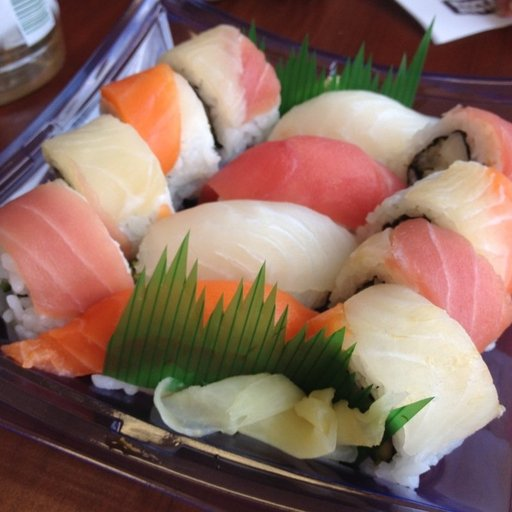

In [154]:
import random
from PIL import Image

# set  the random
random.seed(42)

# get all images paths
image_path_list=list(image_path.glob("*/*/*.jpg"))
#print(image_path)
# get the random image from the image path
random_image=random.choice(image_path_list)
print(random_image)
# get the image class from the path name (the image class is the  name of the directory where the image  stored )
image_class=random_image.parent.stem
#image_class

# open image
img=Image.open(random_image)
img
# print meta data
print(f"random image path:{random_image}")
print(f"image class:{image_class}")
print(f"image height:{img.height}")
print(f"image width:{img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

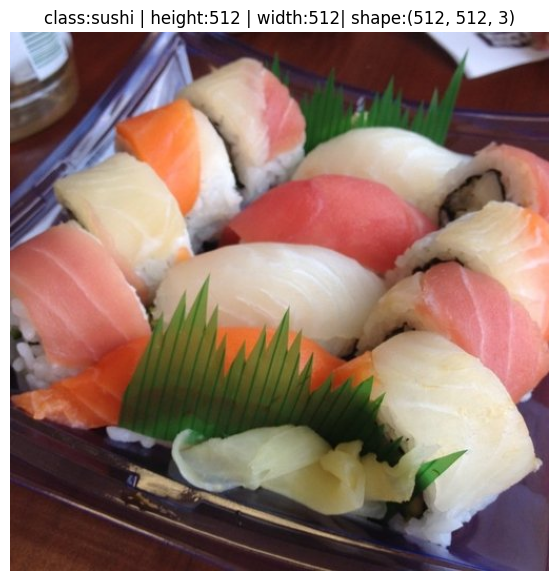

In [155]:
# dot he above with the matplot lib library
import numpy as np
import matplotlib.pyplot as plt

# turn the image in to array
img_arr=np.asarray(img)

#plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_arr)
plt.title(f"class:{image_class} | height:{img.height} | width:{img.width}| shape:{img_arr.shape}")
plt.axis(False)

array([[[205, 218, 252],
        [206, 219, 253],
        [207, 220, 254],
        ...,
        [ 82,  37,  34],
        [ 85,  41,  38],
        [ 88,  44,  41]],

       [[205, 218, 252],
        [206, 219, 253],
        [207, 220, 254],
        ...,
        [ 85,  40,  37],
        [ 89,  45,  42],
        [ 93,  49,  46]],

       [[205, 218, 252],
        [205, 218, 252],
        [207, 220, 254],
        ...,
        [ 89,  44,  39],
        [ 95,  52,  46],
        [100,  57,  51]],

       ...,

       [[100,  53,  37],
        [100,  53,  37],
        [ 98,  49,  34],
        ...,
        [ 68,  41,  60],
        [ 71,  42,  60],
        [ 73,  44,  62]],

       [[ 98,  49,  34],
        [ 99,  50,  35],
        [ 98,  49,  34],
        ...,
        [ 65,  38,  57],
        [ 74,  45,  63],
        [ 74,  45,  63]],

       [[ 93,  44,  29],
        [ 96,  47,  32],
        [ 97,  48,  33],
        ...,
        [ 64,  37,  56],
        [ 76,  47,  65],
        [ 75,  46,  64]]], dtype=uint8)
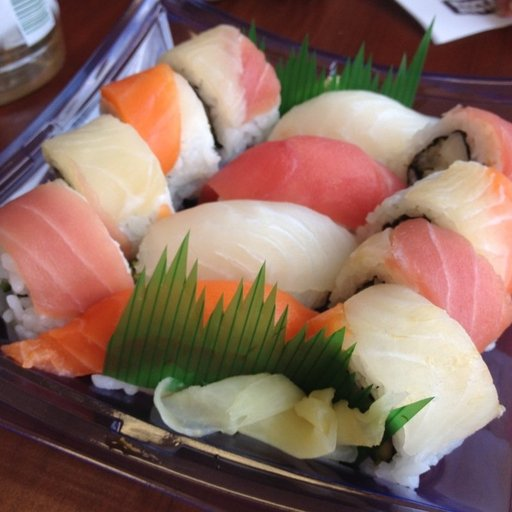

In [156]:
img_arr

Transforming data

before we use our image data with pytorch:
* turn your target data in to tensor ( inour case numerical representation of pur images)
* turn it in to  torch.utlis.data.Dataset and subsequently a
torch.utlis.data.DataLoader well call these dataset and the DataLoader for short

In [157]:
import torch
from torch.utils.data import dataloader
from torchvision import datasets,transforms

Tranforming data with torchvision.transforms

In [158]:
# write a transform for image

data_transform=transforms.Compose(
    [
        # resize image to 64*63
        transforms.Resize((64,64)),
        # flip the images randomly on the horizontal
        transforms.RandomHorizontalFlip(p=0.5),
        # turn the image in to a torch tensor
        transforms.ToTensor()
    ]
)

In [159]:
data_transform(img).shape

torch.Size([3, 64, 64])

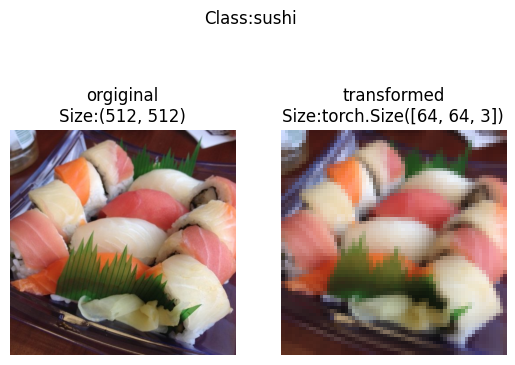

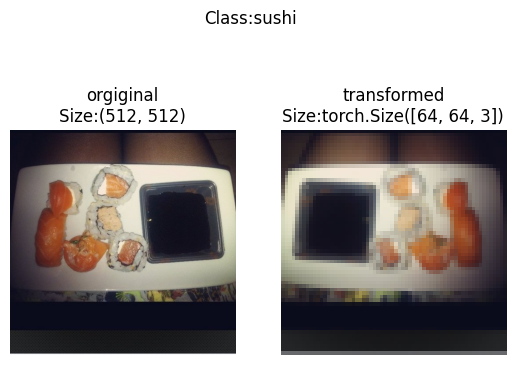

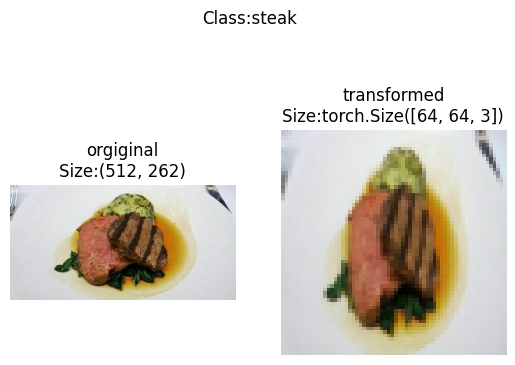

In [160]:
def plot_transformed_image(image_path,transform,n=3,seed=42):
  """ select the random images from the path of images and load /transform
  them then plots the original vs transformed version.
  """
  if seed:
    random.seed(seed)
    random_image=random.sample(image_path,k=n)
  for image_path in random_image:
    transformed_image=transform(Image.open(image_path))
    with Image.open(image_path) as f:
      fig,ax=plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f"orgiginal\nSize:{f.size}")
      ax[0].axis(False)

      #Transform and plot the target image
      transformed_image=transform(f).permute(1,2,0) # we just  chaningthe order chw ->hwc
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"transformed\nSize:{transformed_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class:{image_path.parent.stem}",fontsize=12)
plot_transformed_image(image_path=image_path_list,
                       transform=data_transform,
                       n=3,
                       seed=42)


In [161]:
# loading the data set and image data


Loading the data using ImageFolder
* we can load image  classification data using torchvision,datasets.ImageFolder

In [162]:
# using the image folder
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,
                               transform=data_transform,
                               target_transform=None)
test_data=datasets.ImageFolder(root=test_dir,
                               transform=data_transform,
                               target_transform=None)
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [163]:
# get  the class names
class_names=train_data.classes
class_names
# also able to get the class names as directory
class_name_dir=train_data.class_to_idx
class_name_dir
# get  the len
len(train_data),len(test_data)
# get the label
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [164]:
# index on the train_dataset to get a single image and label
img,label=train_data[0][0],train_data[0][1]
print(f"image tensor:\n{img}")
print(f"shape of the images:{img.shape}")
print(f"image datatype:{img.dtype}")
print(f"image label:{label}")
print(f"label datatype:{type(label)}")


image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

original shape:torch.Size([3, 64, 64])
permute shape:torch.Size([64, 64, 3])


Text(0.5, 1.0, 'pizza')

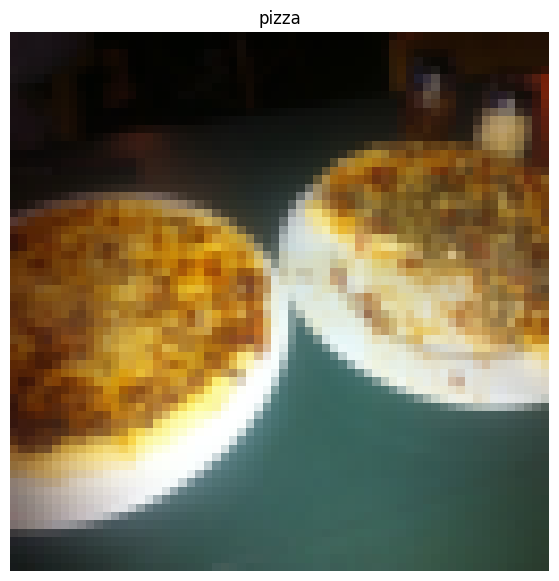

In [165]:
# rearange the order dimesnion
img_permute=img.permute(1,2,0)
# print out the different shapes
print(f"original shape:{img.shape}") # -> chw
print(f"permute shape:{img_permute.shape}") # hwc

#plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(class_names[label])

Turn the data in to dataloader

In [166]:
from torch.utils.data import DataLoader
train_dataloader=DataLoader(dataset=train_data,
                          batch_size=2,
                          num_workers=1,
                          shuffle=True)
test_dataloader=DataLoader(dataset=test_data,
                          batch_size=2,
                          num_workers=1,
                           shuffle=False)
train_dataloader,test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7cc78a4f2270>,
 <torch.utils.data.dataloader.DataLoader at 0x7cc78a53c860>)

In [167]:
len(train_dataloader),len(train_data)

(113, 225)

In [168]:
print(f"train dataloader:{len(train_dataloader)} batches of {train_dataloader.batch_size} images")
print(f"test dataloader:{len(test_dataloader)} batches of {test_dataloader.batch_size} images")

train dataloader:113 batches of 2 images
test dataloader:38 batches of 2 images


iter(dataloader) -> iter can convert  the data loder in to iterable object
next()  -> can fetch the first  coming

In [169]:
img,label=next(iter(train_dataloader))

# batch size will now 1 and yu can change the batch size if like
print(f"image shape : {img.shape}")
print(f"lable shape: {label.shape}")

image shape : torch.Size([2, 3, 64, 64])
lable shape: torch.Size([2])


creating the custom class that loading the image dataset with custom datasets
* want to be able to load the image from file
* want to be able to get class names from Dataset
* want to be able to get the class  as dictionary  from the Dataset

pros:
* create a dataset out of almost any thing
* not limited to pytorch pre built dataset functions

cons:
* even though yu could create dataset of almost any thing it doesnot mean it will work
*  using custom dataset often res in us writing more code which could be prone to errors or performance issues

In [170]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict,List



In [171]:
# instance of  torchvision import transform
train_data.classes,train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

creating a helper function to get the class name
we want a function to:
* Get the class names using os.scandir() to traverse a target directory (ideally the directory is in standard image classification format).
* Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).
* Turn the class names into a dictionary of numerical labels, one for each class.

In [172]:
target_directory=train_dir
print(f"target_directory: {target_directory} ")
# get the class names from the target directory
class_names_found=sorted([entry.name for entry in os.scandir(target_directory) if entry.is_dir()])
class_names_found


target_directory: data/pizza_steak_sushi/train 


['pizza', 'steak', 'sushi']

In [173]:
def find_classes(directory:str)->Tuple[List[str],Dict[str,int]]:
  """
  Finds the class names in a target directory and creates a dictory"""
  # get the class names by scanning the target directory
  classes=sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
  if not classes:
    raise FileNotFoundError(f"could not find any classes in {directory}.. please check file structure")
  class_to_idx={cls_name:i for i,cls_name in enumerate(classes)}
  return classes,class_to_idx

In [174]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

Let's break it down:

* Subclass torch.utils.data.Dataset.
* Initialize our subclass with a targ_dir parameter (the target data directory) and transform parameter (so we have the option to transform our data if needed).
* Create several attributes for paths (the paths of our target images), transform (the transforms we might like to use, this can be None), classes and class_to_idx (from our find_classes() function).
* Create a function to load images from file and return them, this could be using PIL or torchvision.io (for input/output of vision data).
* Overwrite the __len__ method of torch.utils.data.Dataset to return the number of samples in the Dataset, this is recommended but not required. This is so you can call len(Dataset).
* Overwrite the __getitem__ method of torch.utils.data.Dataset to return a single sample from the Dataset, this is required.

In [175]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict,List

# subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  # initializa our custom dataset
  def __init__(self,targ_dir:str,transforme=None) -> None:
   # create the class Attribute
   # it gives the path of image that is in  target directory
   self.paths=list(pathlib.Path(targ_dir).glob("*/*.jpg"))
   # set up transforms
   self.transform=transforme
   #create the class name and class_idx
   self.classes,self.class_to_idx=find_classes(targ_dir)

  def load_image(self, index:int ) -> Image.Image:
    #open  an image via path and return it"
    image_path = self.paths[index]
    return Image.open(image_path)

  # overwrite __len__()
  def __len__(self) -> int :
    #returns the total number of samples
    return len(self.paths)

  # overwrite __getitem__ method to return a particular sample
  def __getitem__(self,index:int) -> Tuple[torch.Tensor,int]:
    #setup index
    image=self.load_image(index)
    class_name=self.paths[index].parent.name
    class_idx=self.class_to_idx[class_name]
    #optional transform the image
    if self.transform:
      return self.transform(image),class_idx
    else:
      return image,class_idx

In [176]:
img,label=train_data[0]
img,label

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [177]:
# create the transform
from torchvision import transforms
train_transform=transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])
test_transform=transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [178]:
# test out I,ageFolderCustom
train_custom_Data=ImageFolderCustom(targ_dir=train_dir,transforme=train_transform)
test_custom_Data=ImageFolderCustom(targ_dir=test_dir,transforme=test_transform)
train_custom_Data,test_custom_Data

(<__main__.ImageFolderCustom at 0x7cc78a3c6930>,
 <__main__.ImageFolderCustom at 0x7cc78a266e40>)

In [179]:
len(train_custom_Data),len(train_data)

(225, 225)

In [180]:
train_custom_Data.classes

['pizza', 'steak', 'sushi']

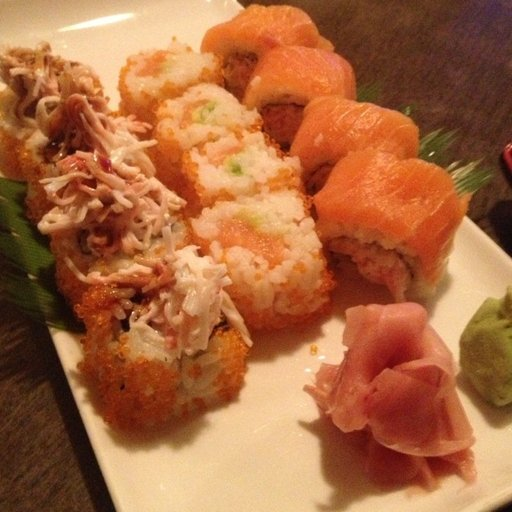

In [181]:
train_custom_Data.load_image(index=0)

In [182]:
# check  for euality between original imagesfolder and custom ones
print(train_data.classes==train_custom_Data.classes)
print(test_data.classes==test_custom_Data.classes)

True
True


Let's create a helper function called display_random_images() that helps us visualize images in our Dataset's.

Specifically, it'll:

* Take in a Dataset and a number of other parameters such as classes (the names of our target classes), the number of images to display (n) and a random seed.
* To prevent the display getting out of hand, we'll cap n at 10 images.
* Set the random seed for reproducible plots (if seed is set).
* Get a list of random sample indexes (we can use Python's random.sample() for this) to plot.
* Setup a matplotlib plot.
* Loop through the random sample indexes found in step 4 and plot them with matplotlib.
* Make sure the sample images are of shape HWC (height, width, color channels) so we can plot them.

In [183]:
# create the function to take in dataset
def display_random_image(dataset:torch.utils.data.Dataset,
                         classes:List[str]=None,
                         n: int=10, # number of images
                         display_shape:bool=True,
                         seed: int =None):

# adjust display if n is too high
  if n >10:
    n=10
    display_shape=False
    print(f"for display,purpose ,n should not be larger than 10,setting 10 and removing shape display")

# set the random seed for reproduce ability
  if seed:
    random.seed(seed)
# get the random sample index
  random_sample_idx=random.sample(range(len(dataset)),k=n)
  plt.figure(figsize=(16,8))
# loop through random index and plot them with matplotlib
  for i, targ_sample in enumerate(random_sample_idx):
    targ_image,targ_label=dataset[targ_sample][0],dataset[targ_sample][1]
    # adjust the tensor dimesnion
    tensor_image_adjust=targ_image.permute(1,2,0) # [chw to hwc]
    #plot adjusted sample
    plt.subplot(1,n,i+1)
    plt.imshow(tensor_image_adjust)
    plt.axis("off")
    if classes:
      title=f"class: {classes[targ_label]}"
      if display_shape:
        title=title+ f"\nshape: {tensor_image_adjust.shape}"
      plt.title(title)

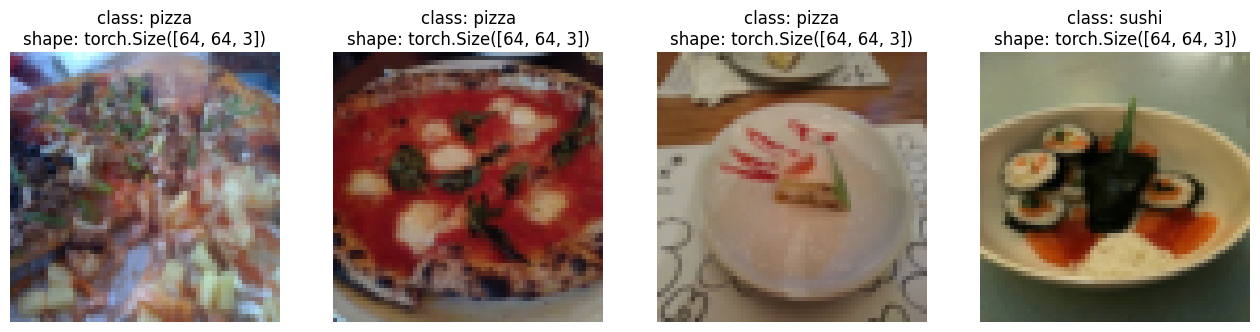

In [184]:
display_random_image(
    train_data,
    n=4,
    classes=class_names,
    seed=None
)

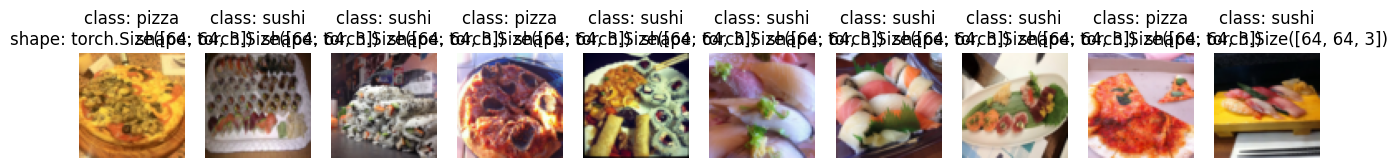

In [185]:
# display random images from custom data set

display_random_image(
    train_custom_Data,
    n=10,
    classes=class_names,
    seed=42
)

In [186]:
# Turn train and test custom Dataset's into DataLoader's
from torch.utils.data import DataLoader
train_cus_dataloader=DataLoader(
    dataset=train_custom_Data,
    batch_size=8,
    num_workers=1,
    shuffle=True
)
test_cus_dataloader=DataLoader(
    dataset=test_custom_Data,
    batch_size=8,
    num_workers=1,
    shuffle=False
)
train_cus_dataloader,test_cus_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7cc78a051850>,
 <torch.utils.data.dataloader.DataLoader at 0x7cc78a053920>)

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

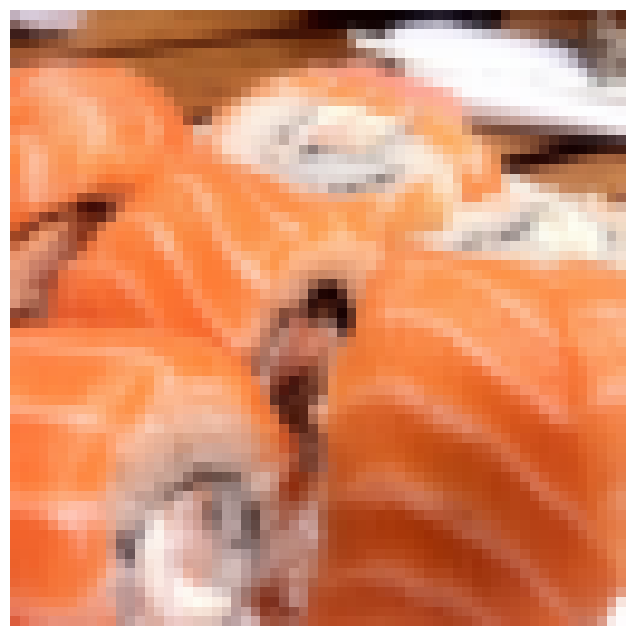

In [187]:
img_c,label_c=next(iter(train_cus_dataloader))
plt.figure(figsize=(16,8))
plt.imshow(img_c[0].permute(1,2,0))
plt.axis(False)

exploring t the data augmentation  by using torch
* what is the data augmentation :
tech used to increase the amount of data by adding slightly modified copies of already existing data or newly created synthetic data  from existing data

In case of the image it apply the different Transformation like rotate,shift,zoon,crop etc.

let look on one particular type of data augmentation used to train pytorch

Link: https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/

In [188]:
# let  look at trivail augment
from torchvision import  transforms

train_transform=transforms.Compose([
    transforms.Resize(size=(224,244)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor(),
])
train_transform_1=transforms.Compose([
    transforms.Resize(size=(224,244)),
    transforms.CenterCrop(size=(124,124)),
    transforms.ToTensor(),
])
train_transform_2=transforms.Compose([
    transforms.Resize(size=(224,244)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])
test_trainform=transforms.Compose([
    transforms.Resize(size=(224,244)),
    transforms.ToTensor(),
])

In [189]:
# get all image path

image_path_list=list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/train/sushi/2590819.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1209865.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/170385.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3360232.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/700405.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2574453.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2641778.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/307738.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/169392.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3353428.jpg')]

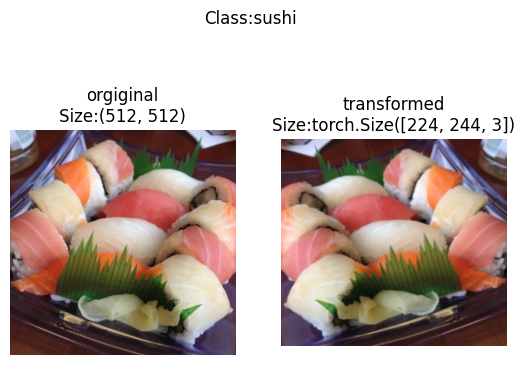

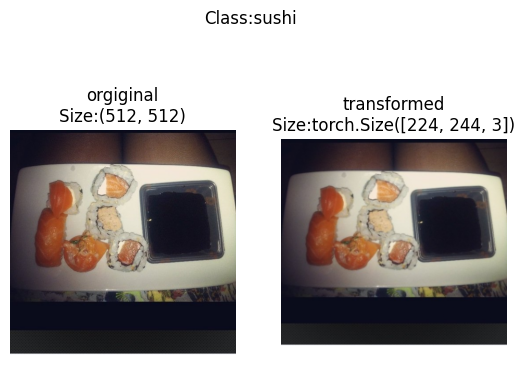

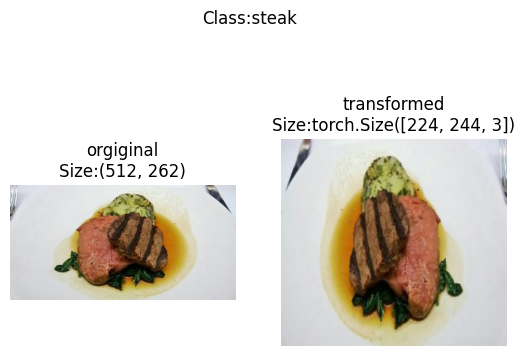

In [190]:
#plot the  random images
plot_transformed_image(image_path=image_path_list,
                       transform=train_transform_2,
                       n=3,
                       seed=42)

MOdel 0 Tiny VGG with out data Augmentation

In [191]:
# create transfrom and loading model for model 0

# create simple transform

simple_transofrm=transforms.Compose(
    [
        transforms.Resize((64,64)),
        transforms.ToTensor()
    ]
)

In [192]:
# load and transform data
from  torchvision import datasets
from torch.utils.data import DataLoader

train_simple_data=datasets.ImageFolder(root=train_dir,
                                      transform=simple_transofrm,
                                      target_transform=None)
test_simple_data=datasets.ImageFolder(root=test_dir,
                                      transform=simple_transofrm,
                                      target_transform=None)
train_simple_data,test_simple_data

# turn dataset in to dataloader

train_simple_dataloader=DataLoader(dataset=train_simple_data,
                                 batch_size=32,
                                 num_workers=1,
                                 shuffle=True)
test_simple_dataloader=DataLoader(dataset=test_simple_data,
                                  batch_size=32,
                                  num_workers=1,
                                  shuffle=False)

Creating the TinyVGG model class

In [213]:
class TinyVGG(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int) -> None:
    super().__init__()
    self.con_block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),

        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.con_block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),

        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)

    )

    # Dynamically calculate the flattened features
    # Create a dummy input tensor to pass through the convolutional blocks
    with torch.inference_mode():
        dummy_input = torch.randn(1, input_shape, 224, 244) # Use the new input image size
        x = self.con_block_1(dummy_input)
        x = self.con_block_2(x)
        flattened_size = x.shape[1] * x.shape[2] * x.shape[3]

    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=flattened_size,
                  out_features=output_shape)
    )
  def forward(self,x):
    x=self.con_block_1(x)
    # print(x.shape) # Keep for debugging if needed
    x=self.con_block_2(x)
    # print(x.shape) # Keep for debugging if needed
    x=self.classifier(x)

    return x

In [194]:
torch.manual_seed(42)

# model_1
model_0=TinyVGG(
    input_shape=3, # number of the colour channels in our image

    hidden_units=10,
    output_shape=len(train_data.classes)
)
model_0


TinyVGG(
  (con_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (con_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

Try  a forward pass on singel image ( to test model)

In [195]:
imge_batch,label_batch=next(iter(train_simple_dataloader))
imge_batch.shape,label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [196]:
model_0.eval()
with torch.inference_mode():
  print(model_0(imge_batch))

torch.Size([32, 10, 30, 30])
torch.Size([32, 10, 13, 13])
tensor([[ 2.2705e-02, -1.3402e-02,  5.1476e-03],
        [ 3.3835e-02, -4.0265e-03,  1.5620e-02],
        [ 2.3261e-02, -1.3165e-02,  1.4540e-02],
        [ 2.6282e-02, -1.5666e-02,  9.9593e-03],
        [ 2.0755e-02, -7.3089e-03,  1.6416e-03],
        [ 1.9382e-02, -9.1043e-03,  1.1140e-02],
        [ 2.5728e-02, -6.2558e-03,  1.5891e-02],
        [ 2.6302e-02, -1.7582e-02,  2.3092e-02],
        [ 2.5158e-02, -1.6822e-02,  1.1187e-02],
        [ 2.7427e-02, -5.1815e-03,  1.0710e-02],
        [ 2.1616e-02, -1.2361e-02,  1.2180e-02],
        [ 2.4985e-02, -1.6081e-02,  6.7354e-03],
        [ 2.3242e-02, -1.6116e-02, -3.6325e-03],
        [ 1.8522e-02, -1.6080e-02,  4.7143e-03],
        [ 2.3099e-02, -1.7124e-02,  3.0674e-05],
        [ 2.3639e-02, -1.2209e-02, -2.2547e-03],
        [ 1.8007e-02, -1.8305e-02,  9.4493e-03],
        [ 2.7234e-02, -1.6499e-02, -2.5206e-03],
        [ 2.4508e-02, -5.9630e-03,  1.9025e-02],
        [ 1

use torch info to get an idea of the shapes going through model

In [197]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo
from torchinfo import summary
summary(model_0,inputsize=[1,3,224,224])


Layer (type:depth-idx)                   Param #
TinyVGG                                  --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       280
│    └─Conv2d: 2-2                       910
│    └─ReLU: 2-3                         --
│    └─MaxPool2d: 2-4                    --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-5                       910
│    └─Conv2d: 2-6                       910
│    └─ReLU: 2-7                         --
│    └─MaxPool2d: 2-8                    --
├─Sequential: 1-3                        --
│    └─Flatten: 2-9                      --
│    └─Linear: 2-10                      5,073
Total params: 8,083
Trainable params: 8,083
Non-trainable params: 0

Train and Test Loop

In [198]:
# create teh train and test loop function
def train_step(model:torch.nn.Module,
                dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device:torch.device):
  # put the model in train mode
  model.train
  # set up the train loss and train accuracy
  train_acc,train_loss=0,0

  # loop through data loader
  for batch, (X,y) in enumerate(dataloader):
    X,y=X.to(device),y.to(device)

    #forward pass
    y_pred=model(X)

    loss=loss_fn(y_pred,y)
    train_loss+=loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
    y_pred_class=torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
    train_acc+=(y_pred_class==y).sum().item()/len(y_pred)

    train_loss=train_loss/len(dataloader)
    train_acc=train_acc/len(dataloader)
    return train_loss,train_acc


def test_step(model:torch.nn.Module,
              dataloader:torch.utils.data.dataloader,
              loss_fn:torch.nn.Module,
              device:torch.device):
  model.eval()
  test_loss,test_acc=0,0
  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
      X,y=X.to(device),y.to(device)
      y_pred=model(X)
      loss=loss_fn(y_pred,y)
      test_loss+=loss.item()
      test_acc+=(torch.argmax(torch.softmax(y_pred,dim=1),dim=1)==y).sum().item()/len(y_pred)

      test_loss=test_loss/len(dataloader)
      test_acc=test_acc/len(dataloader)
      return test_loss,test_acc


training and testing in combine function

In [199]:
from tqdm.auto import tqdm

def train(model:torch.nn.Module,
          train_dataloader:torch.utils.data.dataloader,
          test_dataloader:torch.utils.data.dataloader,
          optimizer:torch.optim.Optimizer,
          loss_fn:torch.nn.Module=nn.CrossEntropyLoss(),
          epochs:int=10,
          device:torch.device="cuda"
          ):
  # create teh emplty result dictionary
  results={
      "train_loss":[],
      "train_acc":[],
      "test_loss":[],
      "test_acc":[]
  }
  for epoch in tqdm(range(epochs)):
    train_loss,train_acc=train_step(model=model,
                                    dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,device=device)
    test_loss,test_acc=test_step(model=model,
                                 dataloader=test_dataloader,
                                 loss_fn=loss_fn,
                                 device=device)
    # print out what is happening
    print(f"epoch: {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")
    # update results dictionary

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)
  # print it
  return results

In [200]:
from ast import mod
# train and evalute model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set the number of the epoch
epoch=5

#recreate an instance of tinyvgg
model_0=TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data.classes)
).to(device)

# setup loss and optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam( params=model_0.parameters(),
                            lr=0.001
)
from timeit import default_timer as timer
start_time=timer()
model_res=train(model=model_0,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=epoch,
      device=device)
end_time=timer()
print(f"total training time: {end_time-start_time}")



  0%|          | 0/5 [00:00<?, ?it/s]

torch.Size([2, 10, 30, 30])
torch.Size([2, 10, 13, 13])
torch.Size([2, 10, 30, 30])
torch.Size([2, 10, 13, 13])
epoch: 0 | train_loss: 0.0097 | train_acc: 0.0044 | test_loss: 0.0268 | test_acc: 0.0263
torch.Size([2, 10, 30, 30])
torch.Size([2, 10, 13, 13])
torch.Size([2, 10, 30, 30])
torch.Size([2, 10, 13, 13])
epoch: 1 | train_loss: 0.0091 | train_acc: 0.0088 | test_loss: 0.0244 | test_acc: 0.0263
torch.Size([2, 10, 30, 30])
torch.Size([2, 10, 13, 13])
torch.Size([2, 10, 30, 30])
torch.Size([2, 10, 13, 13])
epoch: 2 | train_loss: 0.0082 | train_acc: 0.0088 | test_loss: 0.0213 | test_acc: 0.0263
torch.Size([2, 10, 30, 30])
torch.Size([2, 10, 13, 13])
torch.Size([2, 10, 30, 30])
torch.Size([2, 10, 13, 13])
epoch: 3 | train_loss: 0.0101 | train_acc: 0.0000 | test_loss: 0.0200 | test_acc: 0.0263
torch.Size([2, 10, 30, 30])
torch.Size([2, 10, 13, 13])
torch.Size([2, 10, 30, 30])
torch.Size([2, 10, 13, 13])
epoch: 4 | train_loss: 0.0117 | train_acc: 0.0000 | test_loss: 0.0202 | test_acc: 0.

In [201]:
model_res

{'train_loss': [0.009729919180405878,
  0.009130506388908994,
  0.008216272413203147,
  0.010109966835089489,
  0.011743818764138011],
 'train_acc': [0.004424778761061947,
  0.008849557522123894,
  0.008849557522123894,
  0.0,
  0.0],
 'test_loss': [0.026768919668699567,
  0.02443726282370718,
  0.021329028041739213,
  0.02000750366010164,
  0.0202219988170423],
 'test_acc': [0.02631578947368421,
  0.02631578947368421,
  0.02631578947368421,
  0.02631578947368421,
  0.02631578947368421]}

plot the loss curve of model_0

In [202]:
model_res.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [207]:
def plot_loss_curve(result:Dict[str,List[float]]):
  # plotting training curves of a result dictionary
  #get the loss value of the res dictionary
  loss=result["train_loss"]
  test_loss=result["test_loss"]
  # get the acc value of the res dic
  accuracy=result["train_acc"]
  test_accuracy=result["test_acc"]

  # how many epoch there were
  epochs=range(len(loss))

  plt.figure(figsize=(15,7))

  # plot loss
  plt.subplot(1,2,1)
  plt.plot(epochs,loss,label="train_loss")
  plt.plot(epochs,test_loss,label="test_loss")
  plt.title("Loss Curves")
  plt.xlabel("epochs")
  plt.legend()

  # plot accuracy
  plt.subplot(1,2,2)
  plt.plot(epochs,accuracy,label="train_accuracy")
  plt.plot(epochs,test_accuracy,label="test_accuracy")
  plt.title("Accuracy Curves")
  plt.xlabel("epochs")
  plt.legend()

  plt.tight_layout()

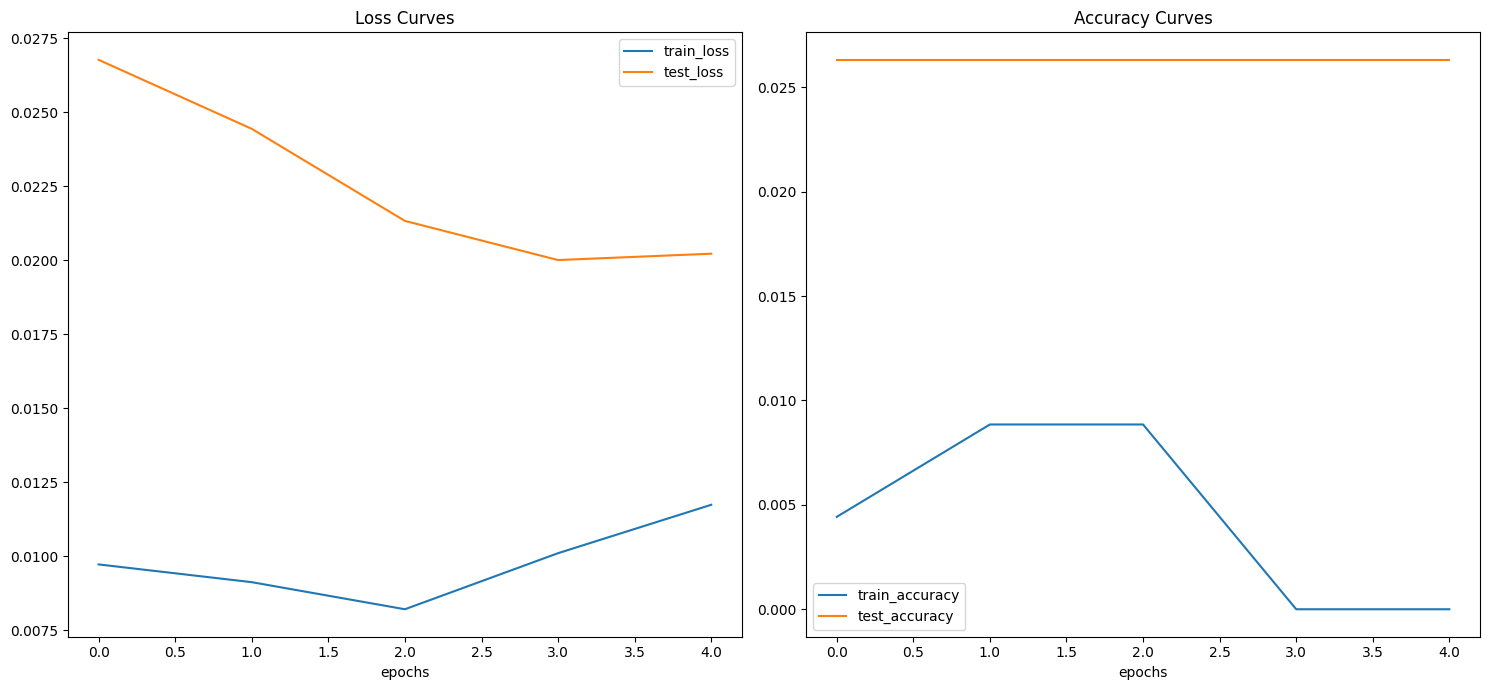

In [208]:
plot_loss_curve(model_res)

Imporving the model with teh data augmentation

In [217]:
from torchvision import transforms

train_transform=transforms.Compose(
    [
        transforms.Resize((64,64)),
        transforms.TrivialAugmentWide(num_magnitude_bins=31),
        transforms.ToTensor()
    ]
)
test_trainform=transforms.Compose(
    [
        transforms.Resize((64,64)),
        transforms.ToTensor()
    ]
)

Turning train and test dataset in to data loader with data augmentation

In [234]:
from torch.utils.data import DataLoader

train_data=datasets.ImageFolder(root=train_dir,
                                transform=train_transform,
                                target_transform=None)
test_data=datasets.ImageFolder(root=test_dir,
                               transform=test_trainform,
                               target_transform=None)
train_data,test_data

train_dataloader=DataLoader(dataset=train_data,
                            batch_size=16,
                            num_workers=1,
                            shuffle=True)
test_dataloader=DataLoader(dataset=test_data,
                           batch_size=16,
                           num_workers=1,
                           shuffle=False)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7cc7978f6d20>,
 <torch.utils.data.dataloader.DataLoader at 0x7cc7977fc3b0>)

construct and train the model

In [235]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_1=TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data.classes)
)
model_1.to(device)



TinyVGG(
  (con_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (con_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=30740, out_features=3, bias=True)
  )
)

In [236]:
#now evaluate the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs=5 # Set epochs to 10 as intended for improved training
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_1.parameters(),
                           lr=0.001)
from timeit import default_timer as timer
start_time=timer()
model_1_res=train(model=model_1,
                  train_dataloader=train_augmented_dataloader, # Use the augmented dataloader
                  test_dataloader=test_non_augmented_dataloader, # Use the non-augmented test dataloader
                  optimizer=optimizer,
                  loss_fn=loss_fn,
                  epochs=epochs,
                  device=device)
end_time=timer()
print(f"Total training time with augmentation: {end_time - start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

epoch: 0 | train_loss: 0.1371 | train_acc: 0.0273 | test_loss: 0.9421 | test_acc: 0.0000
epoch: 1 | train_loss: 0.2131 | train_acc: 0.0508 | test_loss: 0.5380 | test_acc: 0.0000
epoch: 2 | train_loss: 0.1589 | train_acc: 0.0391 | test_loss: 0.2931 | test_acc: 0.2604
epoch: 3 | train_loss: 0.1398 | train_acc: 0.0430 | test_loss: 0.2367 | test_acc: 0.2604
epoch: 4 | train_loss: 0.1583 | train_acc: 0.0469 | test_loss: 0.2359 | test_acc: 0.2812
Total training time with augmentation: 21.913 seconds


plot the loss curve

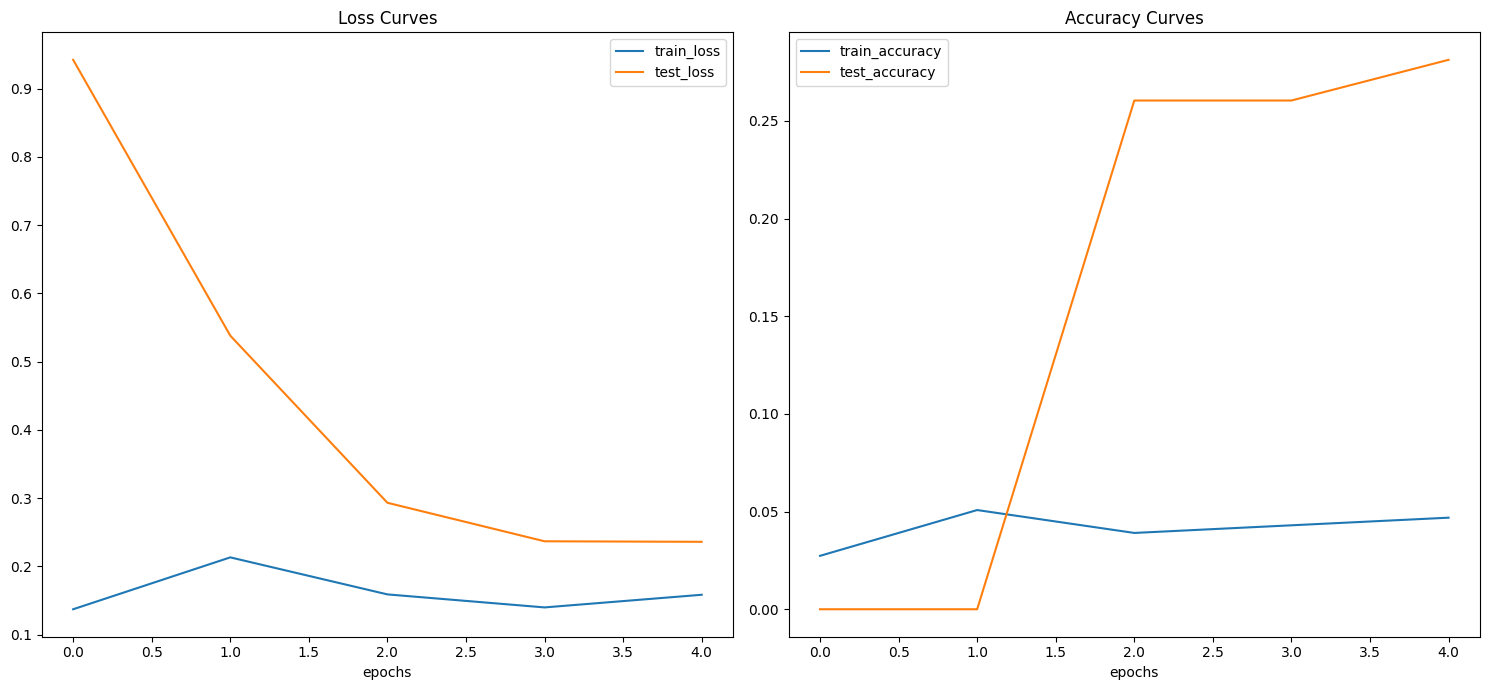

In [237]:
plot_loss_curve(model_1_res)

### Improving Model Performance with Data Augmentation and More Epochs

To improve the accuracy and reduce the loss, we will:
1.  **Apply data augmentation** during training using the `train_transform` which includes resizing, random horizontal flips, and converting to a tensor.
2.  **Train for more epochs** to allow the model more time to learn from the data.
3.  Use the `tqdm` library to display a progress bar during training for better monitoring.

In [209]:
# Create new datasets with data augmentation for training
train_augmented_data = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform,
    target_transform=None
)

test_non_augmented_data = datasets.ImageFolder(
    root=test_dir,
    transform=test_trainform, # Use non-augmented transform for test data
    target_transform=None
)

print(f"Augmented train data: {train_augmented_data}\nNon-augmented test data: {test_non_augmented_data}")

Augmented train data: Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 244), interpolation=bilinear, max_size=None, antialias=True)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )
Non-augmented test data: Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 244), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [210]:
# Create new DataLoaders with augmented data
train_augmented_dataloader = DataLoader(
    dataset=train_augmented_data,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

test_non_augmented_dataloader = DataLoader(
    dataset=test_non_augmented_data,
    batch_size=32,
    num_workers=1,
    shuffle=False
)

print(f"Augmented train DataLoader: {train_augmented_dataloader}\nNon-augmented test DataLoader: {test_non_augmented_dataloader}")

Augmented train DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x7cc78a21b5f0>
Non-augmented test DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x7cc7978a3380>


Now, let's retrain the `TinyVGG` model using these new dataloaders and increase the number of epochs to 10.

In [214]:
# Re-create an instance of TinyVGG for retraining
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_1 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data.classes)
).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model_1.parameters(),
    lr=0.001
)

# Train the model with augmented data and more epochs
from timeit import default_timer as timer
start_time_aug = timer()

model_1_res = train(
    model=model_1,
    train_dataloader=train_augmented_dataloader,
    test_dataloader=test_non_augmented_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10, # Increased epochs
    device=device
)

end_time_aug = timer()
print(f"Total training time with augmentation: {end_time_aug - start_time_aug:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

epoch: 0 | train_loss: 0.1374 | train_acc: 0.0430 | test_loss: 0.6749 | test_acc: 0.0000
epoch: 1 | train_loss: 0.1950 | train_acc: 0.0312 | test_loss: 0.3195 | test_acc: 0.1667
epoch: 2 | train_loss: 0.1358 | train_acc: 0.0664 | test_loss: 0.2072 | test_acc: 0.2604
epoch: 3 | train_loss: 0.1520 | train_acc: 0.0508 | test_loss: 0.2031 | test_acc: 0.2604
epoch: 4 | train_loss: 0.1655 | train_acc: 0.0625 | test_loss: 0.2186 | test_acc: 0.2604
epoch: 5 | train_loss: 0.1510 | train_acc: 0.0547 | test_loss: 0.2838 | test_acc: 0.2604
epoch: 6 | train_loss: 0.1415 | train_acc: 0.0508 | test_loss: 0.3907 | test_acc: 0.0312
epoch: 7 | train_loss: 0.1387 | train_acc: 0.0352 | test_loss: 0.3938 | test_acc: 0.0000
epoch: 8 | train_loss: 0.1347 | train_acc: 0.0352 | test_loss: 0.3561 | test_acc: 0.0729
epoch: 9 | train_loss: 0.1339 | train_acc: 0.0547 | test_loss: 0.3490 | test_acc: 0.1667
Total training time with augmentation: 43.208 seconds


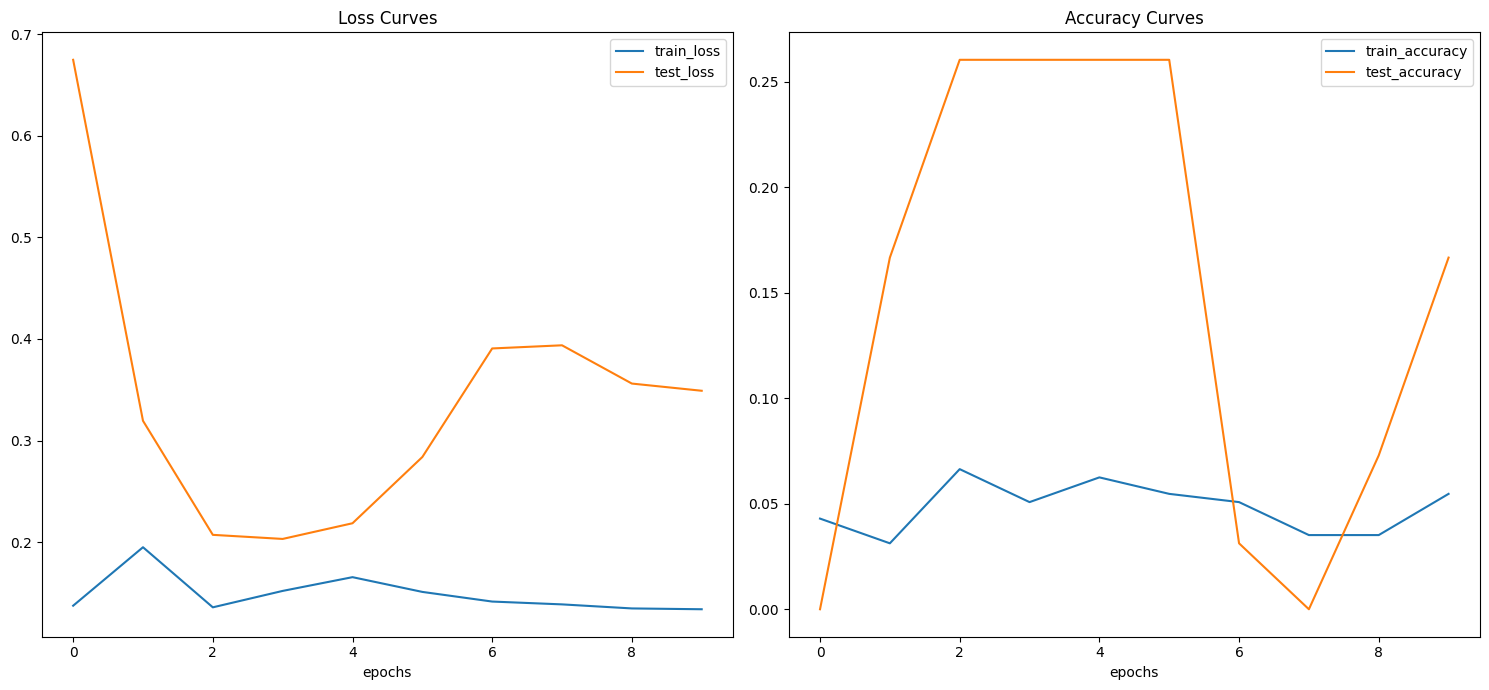

In [215]:
# Plot the loss curves for the model trained with augmentation
plot_loss_curve(model_1_res)

compare the result

<Axes: title={'center': 'model_1'}>

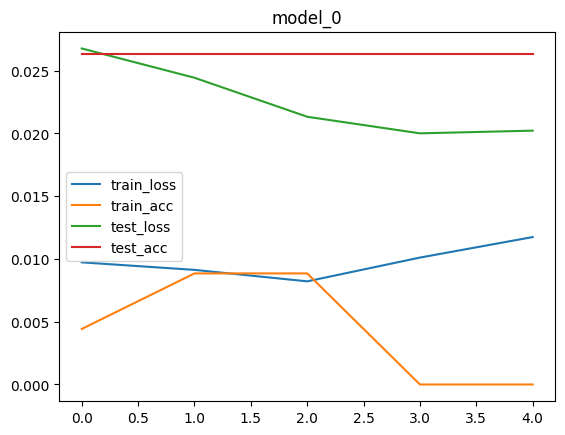

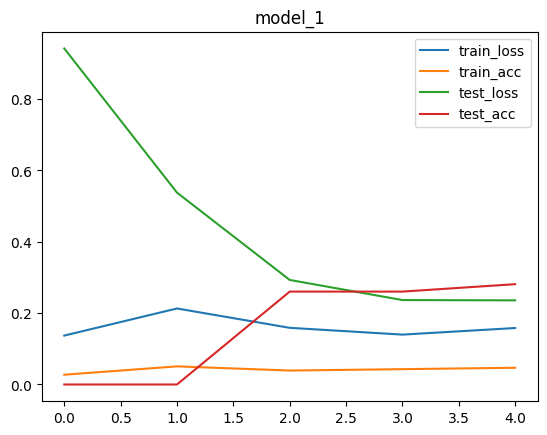

In [238]:
import pandas as pd
model_0_df=pd.DataFrame(model_res)
model_1_df=pd.DataFrame(model_1_res)
model_0_df.plot(title="model_0")
model_1_df.plot(title="model_1")